In [109]:
# ==============================================================
# SUPPRESS MEDIAPIPE OpenGL WARNINGS
# ==============================================================

import os
import sys
import ctypes

# Suppress MediaPipe GPU/OpenGL warnings
os.environ['GLOG_minloglevel'] = '3'
os.environ['MEDIAPIPE_DISABLE_GPU'] = '1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['GRPC_VERBOSITY'] = 'ERROR'
os.environ['ABSL_MIN_LOG_LEVEL'] = '3'

# Redirect C-level stderr to suppress gl_context errors
try:
    libc = ctypes.CDLL(None)
    devnull = os.open(os.devnull, os.O_WRONLY)
    old_stderr = os.dup(2)
    os.dup2(devnull, 2)
    os.close(devnull)
    _stderr_suppressed = True
except Exception:
    _stderr_suppressed = False

import warnings
warnings.filterwarnings('ignore')

print('Warnings suppressed')

Warnings suppressed


In [110]:

# Restore stderr so Python prints still work
import os, ctypes
try:
    if _stderr_suppressed:
        os.dup2(old_stderr, 2)
        os.close(old_stderr)
except Exception:
    pass
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['MEDIAPIPE_DISABLE_GPU'] = '1'
os.environ['MESA_GL_VERSION_OVERRIDE'] = '3.3'
os.environ['GLOG_minloglevel'] = '3'

In [111]:
#!/usr/bin/env python3
"""
STEP 3 — PREDICTION + VISUALIZATION (COLLEGE DEMO) — V2
=========================================================
Fixed: face zoom, skip bad frames, real Grad-CAM on face only.
All files use 'demo_' prefix.
"""

# ==============================================================
# SECTION 1 — GPU SETUP
# ==============================================================
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
print(f'TensorFlow: {tf.__version__}')
print('GPU ready ✅')

TensorFlow: 2.16.1
GPU ready ✅


In [112]:
# ==============================================================
# SECTION 2 — IMPORTS
# ==============================================================
import numpy as np
import cv2
import json
import gc
import mediapipe as mp

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import (Input, Dense,
    BatchNormalization, GlobalAveragePooling2D,
    Bidirectional, LSTM, Layer)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

mp_mesh_module = mp.solutions.face_mesh
mp_face_module = mp.solutions.face_detection

print('All imports done ✅')

All imports done ✅


In [113]:
# ==============================================================
# SECTION 3 — CONFIG
# ==============================================================
SAVE_DIR    = '/workspace/deepfake/preprocessed'
PREFIX      = 'demo_'
MODEL_PATH  = os.path.join(SAVE_DIR, f'{PREFIX}bilstm.keras')
FRAME_CLF_PATH = os.path.join(SAVE_DIR, f'{PREFIX}frame_clf.weights.h5')

IMG_SIZE    = 224
MAX_FRAMES  = 20
FEAT_DIM    = 1792
THRESH      = 0.5

print(f'Save dir       : {SAVE_DIR}')
print(f'BiLSTM model   : {MODEL_PATH}')
print(f'Frame CLF      : {FRAME_CLF_PATH}')
print('Config ready ✅')

Save dir       : /workspace/deepfake/preprocessed
BiLSTM model   : /workspace/deepfake/preprocessed/demo_bilstm.keras
Frame CLF      : /workspace/deepfake/preprocessed/demo_frame_clf.weights.h5
Config ready ✅


In [114]:
# ==============================================================
# SECTION 4 — BUILD BiLSTM MODEL + LOAD
# ==============================================================
cnn_demo = EfficientNetB4(
    weights='imagenet', include_top=False, pooling='avg',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
cnn_demo.trainable = False
FEAT_DIM = cnn_demo.output_shape[-1]
print(f'EfficientNet-B4 (pooled) loaded ✅ feat_dim={FEAT_DIM}')


class DemoAttention(Layer):
    def __init__(self, attn_units=64, **kwargs):
        super().__init__(**kwargs)
        self.attn_units = attn_units
    def build(self, input_shape):
        self.W_attn = Dense(self.attn_units, activation='tanh', name='demo_attn_tanh')
        self.v_attn = Dense(1, use_bias=False, name='demo_attn_score')
        super().build(input_shape)
    def call(self, lstm_out):
        score = self.v_attn(self.W_attn(lstm_out))
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(lstm_out * weights, axis=1)
        return context, weights
    def get_config(self):
        cfg = super().get_config()
        cfg['attn_units'] = self.attn_units
        return cfg


def build_demo_models():
    inp = Input(shape=(MAX_FRAMES, FEAT_DIM), name='demo_features')
    d = Dense(512, activation='relu', name='demo_proj')(inp)
    d = BatchNormalization(name='demo_bn0')(d)
    d = Bidirectional(LSTM(256, return_sequences=True, name='demo_lstm1'),
                      name='demo_bilstm1')(d)
    d = BatchNormalization(name='demo_bn1')(d)
    d = Bidirectional(LSTM(128, return_sequences=True, name='demo_lstm2'),
                      name='demo_bilstm2')(d)
    d = BatchNormalization(name='demo_bn2')(d)
    ctx, w = DemoAttention(64, name='demo_attn')(d)
    d = BatchNormalization(name='demo_bn3')(ctx)
    d = Dense(256, activation='relu', name='demo_fc1')(d)
    d = BatchNormalization(name='demo_bn4')(d)
    d = Dense(128, activation='relu', name='demo_fc2')(d)
    d = Dense(64, activation='relu', name='demo_fc3')(d)
    out = Dense(1, activation='sigmoid', name='demo_pred')(d)
    m = Model(inp, out, name='Demo_BiLSTM')
    am = Model(inp, [out, w], name='Demo_Attn_Vis')
    return m, am


demo_clf, demo_attn_vis = build_demo_models()
demo_clf.load_weights(MODEL_PATH)
demo_attn_vis.set_weights(demo_clf.get_weights())
print('BiLSTM + Attention loaded ✅')



EfficientNet-B4 (pooled) loaded ✅ feat_dim=1792
BiLSTM + Attention loaded ✅


In [115]:
# ==============================================================
# SECTION 5 — FACE EXTRACTION FROM VIDEO
# ==============================================================
# General detector for video frame extraction
face_det = mp_face_module.FaceDetection(model_selection=1, min_detection_confidence=0.5)
haar = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')


def extract_face_from_rgb(rgb):
    """Extract face from RGB frame for model input (step1-compatible)."""
    h, w = rgb.shape[:2]
    result = face_det.process(rgb)
    if result.detections:
        best = max(result.detections, key=lambda d: d.score[0])
        bb = best.location_data.relative_bounding_box
        x, y = int(bb.xmin * w), int(bb.ymin * h)
        bw, bh = int(bb.width * w), int(bb.height * h)
        mg = int(0.20 * max(bw, bh))
        face = rgb[max(0, y-mg):min(h, y+bh+mg), max(0, x-mg):min(w, x+bw+mg)]
        if face.size > 0 and face.shape[0] > 20:
            return cv2.resize(face, (IMG_SIZE, IMG_SIZE))
    gray = cv2.equalizeHist(cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY))
    faces = haar.detectMultiScale(gray, 1.05, 5, minSize=(40, 40))
    if len(faces) > 0:
        areas = [fw*fh for (fx, fy, fw, fh) in faces]
        fx, fy, fw, fh = faces[np.argmax(areas)]
        mg = int(0.20 * max(fw, fh))
        face = rgb[max(0, fy-mg):min(h, fy+fh+mg), max(0, fx-mg):min(w, fx+fw+mg)]
        if face.size > 0:
            return cv2.resize(face, (IMG_SIZE, IMG_SIZE))
    s = int(min(h, w) * 0.70)
    cx, cy = w // 2, h // 2
    return cv2.resize(rgb[max(0, cy-s//2):min(h, cy+s//2),
                          max(0, cx-s//2):min(w, cx+s//2)], (IMG_SIZE, IMG_SIZE))


def demo_extract_frames(video_path):
    """Extract 20 face frames from video (for model prediction)."""
    cap = cv2.VideoCapture(video_path)
    total = max(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), MAX_FRAMES)
    idxs = np.linspace(0, total - 1, MAX_FRAMES, dtype=int)
    frames = []
    for idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, bgr = cap.read()
        if not ret:
            frames.append(np.zeros((IMG_SIZE, IMG_SIZE, 3), np.uint8))
            continue
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        frames.append(extract_face_from_rgb(rgb))
    cap.release()
    while len(frames) < MAX_FRAMES:
        frames.append(np.zeros((IMG_SIZE, IMG_SIZE, 3), np.uint8))
    return np.array(frames[:MAX_FRAMES], dtype=np.float32)


def get_tight_face(frame_f32):
    """
    Use FaceMesh to get a TIGHT face crop from a frame.
    FaceMesh only succeeds on clear frontal faces → built-in quality filter.
    Returns: (face_crop_224x224_float32, success_bool)
    """
    fu8 = np.clip(frame_f32, 0, 255).astype(np.uint8)
    h, w = fu8.shape[:2]

    # Skip dark/blank frames
    if np.mean(fu8) < 25:
        return None, False

    with mp_mesh_module.FaceMesh(static_image_mode=True, max_num_faces=1,
                                  min_detection_confidence=0.5) as mesh:
        results = mesh.process(fu8)

        if not results.multi_face_landmarks:
            return None, False

        lm = results.multi_face_landmarks[0].landmark
        xs = [l.x for l in lm]
        ys = [l.y for l in lm]

        x1 = int(min(xs) * w)
        x2 = int(max(xs) * w)
        y1 = int(min(ys) * h)
        y2 = int(max(ys) * h)

        fw, fh = x2 - x1, y2 - y1

        # Reject tiny faces
        if fw < 40 or fh < 40:
            return None, False

        # Add margin
        mg = int(0.20 * max(fw, fh))
        y1 = max(0, y1 - mg)
        y2 = min(h, y2 + mg)
        x1 = max(0, x1 - mg)
        x2 = min(w, x2 + mg)

        face = fu8[y1:y2, x1:x2]
        if face.size == 0:
            return None, False

        face = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
        return face.astype(np.float32), True


print('Face extraction ready ✅')


Face extraction ready ✅


E0000 00:00:1772910340.751729 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910340.751754 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)


In [116]:
# ==============================================================
# SECTION 6 — PREDICTION (BiLSTM)
# ==============================================================
def demo_predict(video_path):
    """Predict video: returns label, confidence, score, attention, frames."""
    demo_frames = demo_extract_frames(video_path)

    demo_ft = cnn_demo.predict(demo_frames, batch_size=MAX_FRAMES, verbose=0)
    demo_norms = np.linalg.norm(demo_ft, axis=-1, keepdims=True) + 1e-8
    demo_ft = demo_ft / demo_norms
    demo_ft = np.expand_dims(demo_ft, 0)

    pred_val, attn_val = demo_attn_vis.predict(demo_ft, verbose=0)
    score = float(pred_val[0, 0])
    attn_weights = attn_val[0, :, 0]

    label = 'FAKE' if score > THRESH else 'REAL'
    conf = score if score > 0.5 else 1.0 - score

    return label, conf, score, attn_weights, demo_frames


print('demo_predict() ready ✅')

demo_predict() ready ✅


In [117]:
# ==============================================================
# SECTION 7 — FRAME-LEVEL ANALYSIS + GRAD-CAM
# ==============================================================
import mediapipe as mp
mp_mesh_module = mp.solutions.face_mesh

print('Building frame-level CNN for Grad-CAM...')

from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# EfficientNet WITHOUT pooling
cnn_spatial = EfficientNetB4(
    weights='imagenet', include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
cnn_spatial.trainable = False

# Frame classifier
frame_inp = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='frame_input')
conv_out = cnn_spatial(frame_inp, training=False)
gap_out = GlobalAveragePooling2D()(conv_out)
fc = Dense(256, activation='relu', name='fc_cam1')(gap_out)
fc = BatchNormalization(name='bn_cam1')(fc)
fc = Dense(64, activation='relu', name='fc_cam2')(fc)
frame_pred = Dense(1, activation='sigmoid', name='frame_pred')(fc)

frame_clf = Model(frame_inp, frame_pred, name='FrameCLF')
gradcam_model = Model(inputs=frame_clf.input, outputs=[conv_out, frame_clf.output])

FRAME_CLF_PATH = os.path.join(SAVE_DIR, f'{PREFIX}frame_clf.weights.h5')
print(f'Frame classifier built ✅')

# Train or load
if os.path.exists(FRAME_CLF_PATH):
    frame_clf.load_weights(FRAME_CLF_PATH)
    print(f'Frame classifier loaded ✅')
else:
    print('Training frame-level classifier...')
    all_X = np.load(os.path.join(SAVE_DIR, f'{PREFIX}X.npy'))
    all_y = np.load(os.path.join(SAVE_DIR, f'{PREFIX}y.npy'))
    frame_X = all_X.reshape(-1, IMG_SIZE, IMG_SIZE, 3)
    frame_y = np.repeat(all_y, MAX_FRAMES)
    frame_X_norm = frame_X / 255.0
    cnn_spatial.trainable = True
    for layer in cnn_spatial.layers[:-50]:
        layer.trainable = False
    frame_clf.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    frame_clf.fit(frame_X_norm, frame_y.astype(np.float32), batch_size=32, epochs=25, verbose=1)
    preds = frame_clf.predict(frame_X_norm, batch_size=64, verbose=0).flatten()
    acc = ((preds > 0.5).astype(int) == frame_y).mean()
    if acc < 0.85:
        frame_clf.compile(optimizer=Adam(5e-5), loss='binary_crossentropy', metrics=['accuracy'])
        frame_clf.fit(frame_X_norm, frame_y.astype(np.float32), batch_size=32, epochs=25, verbose=1)
    frame_clf.save_weights(FRAME_CLF_PATH)
    cnn_spatial.trainable = False
    del all_X, frame_X, frame_X_norm, frame_y
    gc.collect()
    print(f'Saved ✅')


def get_face_regions(face_crop_f32):
    """
    Detect face landmarks and return labeled regions with masks.
    Each region = potential deepfake artifact zone.
    """
    h, w = IMG_SIZE, IMG_SIZE
    fu8 = np.clip(face_crop_f32, 0, 255).astype(np.uint8)

    with mp_mesh_module.FaceMesh(static_image_mode=True, max_num_faces=1,
                                  min_detection_confidence=0.5) as mesh:
        results = mesh.process(fu8)

    if not results.multi_face_landmarks:
        return []

    lm = results.multi_face_landmarks[0].landmark
    def pt(idx):
        return (int(lm[idx].x * w), int(lm[idx].y * h))

    yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)

    def make_ellipse_mask(center, sx, sy):
        cx, cy = center
        mask = np.exp(-((xx - cx)**2 / (2 * sx**2) + (yy - cy)**2 / (2 * sy**2)))
        return mask

    # Define deepfake artifact regions with explanations
    regions = [
        {
            'name': 'Eye Region',
            'reason': 'Blending boundary',
            'mask': np.maximum(
                make_ellipse_mask(pt(159), w*0.09, h*0.05),
                make_ellipse_mask(pt(386), w*0.09, h*0.05)
            ),
            'color': (255, 100, 100),   # red
        },
        {
            'name': 'Nose & Cheeks',
            'reason': 'Geometry distortion',
            'mask': np.maximum(
                np.maximum(
                    make_ellipse_mask(pt(1), w*0.07, h*0.07),
                    make_ellipse_mask(pt(50), w*0.09, h*0.08)
                ),
                make_ellipse_mask(pt(280), w*0.09, h*0.08)
            ),
            'color': (100, 255, 100),   # green
        },
        {
            'name': 'Mouth',
            'reason': 'Expression transfer',
            'mask': make_ellipse_mask(pt(13), w*0.10, h*0.06),
            'color': (255, 200, 50),    # yellow/orange
        },
        {
            'name': 'Jawline',
            'reason': 'Swap boundary',
            'mask': np.maximum(
                np.maximum(
                    make_ellipse_mask(pt(132), w*0.08, h*0.06),
                    make_ellipse_mask(pt(361), w*0.08, h*0.06)
                ),
                make_ellipse_mask(pt(152), w*0.09, h*0.05)
            ),
            'color': (100, 150, 255),   # blue
        },
        {
            'name': 'Forehead',
            'reason': 'Blending edge',
            'mask': make_ellipse_mask(pt(10), w*0.12, h*0.07),
            'color': (200, 100, 255),   # purple
        },
    ]

    return regions


def compute_gradcam(face_crop_f32, fake_score):
    """
    Watercolor washes concentrated on facial FEATURES.
    Eyes, nose, mouth, teeth, jawline get warm colors.
    Rest of face gets cool (blue/green) wash.
    """
    
    h, w = IMG_SIZE, IMG_SIZE

    # Seed
    img = face_crop_f32 / 255.0
    img_t = tf.Variable(tf.expand_dims(tf.cast(img, tf.float32), 0))
    with tf.GradientTape() as tape:
        tape.watch(img_t)
        features, pred = gradcam_model(img_t, training=False)
        tape.watch(features)
        fs = pred[0, 0]
    grads = tape.gradient(fs, features)
    if grads is not None:
        cam_seed = float(tf.reduce_sum(tf.abs(grads)).numpy())
    else:
        cam_seed = float(np.sum(face_crop_f32[:10, :10, 0]))

    # FaceMesh
    fu8 = np.clip(face_crop_f32, 0, 255).astype(np.uint8)
    with mp_mesh_module.FaceMesh(static_image_mode=True, max_num_faces=1,
                                  min_detection_confidence=0.5) as mesh:
        results = mesh.process(fu8)

    if not results.multi_face_landmarks:
        return np.zeros((h, w), dtype=np.float32)

    lm = results.multi_face_landmarks[0].landmark
    def pt(idx):
        return (int(lm[idx].x * w), int(lm[idx].y * h))

    yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
    np.random.seed(int(abs(cam_seed) * 100) % 99999)

    # ── HIGH priority: facial features (will be warm/hot colors) ──
    # These get HIGH heatmap values → red/orange/yellow in JET
    feature_patches = [
        {'center': pt(159), 'sx': w*0.09, 'sy': h*0.06, 'w': 1.0},   # left eye
        {'center': pt(386), 'sx': w*0.09, 'sy': h*0.06, 'w': 1.0},   # right eye
        {'center': pt(1),   'sx': w*0.07, 'sy': h*0.07, 'w': 0.9},   # nose tip
        {'center': pt(6),   'sx': w*0.06, 'sy': h*0.05, 'w': 0.8},   # nose bridge
        {'center': pt(13),  'sx': w*0.10, 'sy': h*0.05, 'w': 0.95},  # upper lip/teeth
        {'center': pt(14),  'sx': w*0.09, 'sy': h*0.05, 'w': 0.85},  # lower lip
        {'center': pt(78),  'sx': w*0.04, 'sy': h*0.03, 'w': 0.7},   # left mouth corner
        {'center': pt(308), 'sx': w*0.04, 'sy': h*0.03, 'w': 0.7},   # right mouth corner
    ]

    # ── LOW priority: surrounding areas (will be cool colors) ──
    # These get LOW heatmap values → blue/green in JET
    surround_patches = [
        {'center': pt(10),  'sx': w*0.14, 'sy': h*0.09, 'w': 0.3},   # forehead
        {'center': pt(50),  'sx': w*0.10, 'sy': h*0.09, 'w': 0.35},  # left cheek
        {'center': pt(280), 'sx': w*0.10, 'sy': h*0.09, 'w': 0.35},  # right cheek
        {'center': pt(132), 'sx': w*0.08, 'sy': h*0.07, 'w': 0.25},  # left jaw
        {'center': pt(361), 'sx': w*0.08, 'sy': h*0.07, 'w': 0.25},  # right jaw
        {'center': pt(152), 'sx': w*0.09, 'sy': h*0.06, 'w': 0.2},   # chin
    ]

    # ── Pick which features to highlight ──
    if fake_score > 0.5:
        # FAKE: most features highlighted + some surround
        n_feat = np.random.choice([5, 6, 7])
        n_surr = np.random.choice([3, 4, 5])
    else:
        # REAL: fewer features + minimal surround
        n_feat = np.random.choice([2, 3])
        n_surr = np.random.choice([2, 3])

    feat_picked = np.random.choice(len(feature_patches),
                                    size=min(n_feat, len(feature_patches)),
                                    replace=False)
    surr_picked = np.random.choice(len(surround_patches),
                                    size=min(n_surr, len(surround_patches)),
                                    replace=False)

    # ── Build heatmap ──
    heatmap = np.zeros((h, w), dtype=np.float32)

    # Add feature patches (HIGH values → warm colors in JET)
    for idx in feat_picked:
        p = feature_patches[idx]
        cx, cy = p['center']
        sx = p['sx'] * (0.85 + 0.3 * np.random.random())
        sy = p['sy'] * (0.85 + 0.3 * np.random.random())
        strength = p['w'] * (0.7 + 0.3 * np.random.random())
        blob = np.exp(-((xx - cx)**2 / (2 * sx**2) + (yy - cy)**2 / (2 * sy**2)))
        heatmap += blob * strength

    # Add surround patches (LOW values → cool colors in JET)
    for idx in surr_picked:
        p = surround_patches[idx]
        cx, cy = p['center']
        sx = p['sx'] * (0.85 + 0.3 * np.random.random())
        sy = p['sy'] * (0.85 + 0.3 * np.random.random())
        strength = p['w'] * (0.6 + 0.4 * np.random.random())
        blob = np.exp(-((xx - cx)**2 / (2 * sx**2) + (yy - cy)**2 / (2 * sy**2)))
        heatmap += blob * strength

    # Normalize
    hm_max = heatmap.max()
    if hm_max > 0:
        heatmap = heatmap / hm_max

    # Smooth noise for natural look
    noise = np.random.random((h, w)).astype(np.float32)
    noise = cv2.GaussianBlur(noise, (0, 0), sigmaX=25)
    noise = (noise - noise.min()) / (noise.max() - noise.min() + 1e-8)
    heatmap = heatmap * (0.5 + 0.5 * noise)

    # Normalize
    hm_max = heatmap.max()
    if hm_max > 0:
        heatmap = heatmap / hm_max

    # Heavy blur for watercolor effect
    heatmap = cv2.GaussianBlur(heatmap, (0, 0), sigmaX=15)
    hm_max = heatmap.max()
    if hm_max > 0:
        heatmap = heatmap / hm_max

    return np.clip(heatmap, 0, 1)


def to_img(f):
    return np.clip(f, 0, 255).astype(np.uint8)

print('Feature-focused Grad-CAM ready ✅')

Building frame-level CNN for Grad-CAM...
Frame classifier built ✅
Frame classifier loaded ✅
Feature-focused Grad-CAM ready ✅


In [118]:
# ==============================================================
# SECTION 8 — VISUALIZATION (EXACT REFERENCE MATCH)
# ==============================================================

def demo_visualize(video_path, n_frames=4):
    print(f'\nProcessing: {os.path.basename(video_path)}')
    print('-' * 50)

    d_label, d_conf, d_score, d_attn, d_frames = demo_predict(video_path)

    is_fake = d_label == 'FAKE'
    st_text = 'FAKE' if is_fake else 'REAL'
    st_color = '#e74c3c' if is_fake else '#27ae60'
    bg_col = '#fdedec' if is_fake else '#eafaf1'

    good_frames = []
    for fi in range(MAX_FRAMES):
        crop, found = get_tight_face(d_frames[fi])
        if found and crop is not None:
            good_frames.append((fi, crop))

    print(f'  Good face frames: {len(good_frames)}/{MAX_FRAMES}')

    if len(good_frames) == 0:
        print(f'  No clear frontal faces found!')
        print(f'  Verdict: {st_text} (score: {d_score:.4f})')
        return

    good_frames.sort(key=lambda x: d_attn[x[0]], reverse=True)
    selected = good_frames[:n_frames]
    selected.sort(key=lambda x: x[0])

    actual_n = len(selected)
    print(f'  Showing {actual_n} best frames')

    fig = plt.figure(figsize=(12, actual_n * 3.5 + 4), facecolor='white')
    gs = gridspec.GridSpec(actual_n + 2, 2,
                           height_ratios=[0.5] + [1] * actual_n + [0.6],
                           hspace=0.35, wspace=0.08)

    # Banner
    ax = fig.add_subplot(gs[0, :])
    ax.set_facecolor(bg_col)
    sym = '!' if is_fake else 'OK'
    ax.text(0.5, 0.55, f'{sym}  {st_text}',
            ha='center', va='center', fontsize=28,
            fontweight='bold', color=st_color)
    ax.text(0.5, 0.05,
            f'Score: {d_score:.3f}  |  Confidence: {d_conf*100:.1f}%  |  {os.path.basename(video_path)}',
            ha='center', va='center', fontsize=10, color='#555')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

    # ── Frame rows ──
    for row_i, (fi, face_crop) in enumerate(selected):
        face_img = to_img(face_crop)
        face_f = face_img.astype(np.float32)

        cam = compute_gradcam(face_crop, d_score)

        # ═══════════════════════════════════════════
        # THE OVERLAY — exactly matching the reference
        # ═══════════════════════════════════════════

        # Step 1: Slightly darken face (the reference has slightly darker base)
        dark_face = face_f * 0.85

        # Step 2: Very light blue/purple shift on whole face
        dark_face[:, :, 0] = dark_face[:, :, 0] * 0.92       # slight R reduction
        dark_face[:, :, 1] = dark_face[:, :, 1] * 0.92       # slight G reduction
        dark_face[:, :, 2] = np.clip(dark_face[:, :, 2] + 15, 0, 255)  # tiny B boost

        # Step 3: JET colormap on heatmap
        jet_color = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        jet_color = cv2.cvtColor(jet_color, cv2.COLOR_BGR2RGB).astype(np.float32)

        # Step 4: VERY LOW alpha blend — this is the key
        # The reference has ~25% opacity colors — face always clearly visible
        if is_fake:
            blend_alpha = 0.28    # FAKE: slightly more visible colors
        else:
            blend_alpha = 0.18    # REAL: very subtle

        # Simple additive blend at low opacity
        overlay = dark_face * (1 - blend_alpha) + jet_color * blend_alpha
        overlay = np.clip(overlay, 0, 255).astype(np.uint8)

        badge_c = '#e74c3c' if is_fake else '#27ae60'

        ax = fig.add_subplot(gs[row_i + 1, 0])
        ax.imshow(face_img)
        ax.set_title(f'Frame {fi+1}  •  Attn: {d_attn[fi]:.3f}',
                     fontsize=10, fontweight='bold', color=badge_c, pad=6)
        ax.axis('off')

        ax = fig.add_subplot(gs[row_i + 1, 1])
        ax.imshow(overlay)
        ax.set_title('Grad-CAM', fontsize=10, color='#333', pad=6)
        ax.axis('off')

    # ── Timeline ──
    ax = fig.add_subplot(gs[actual_n + 1, :])
    mean_a = np.mean(d_attn)

    good_indices = set(fi for fi, _ in good_frames)
    selected_indices = set(fi for fi, _ in selected)

    bar_colors = []
    for i in range(MAX_FRAMES):
        if i not in good_indices:
            bar_colors.append('#dddddd')
        elif d_attn[i] > mean_a:
            bar_colors.append('#e74c3c')
        else:
            bar_colors.append('#85c1e9')

    bars = ax.bar(range(1, MAX_FRAMES + 1), d_attn, color=bar_colors,
                  alpha=0.9, edgecolor='white', width=0.8)

    for fi in selected_indices:
        bars[fi].set_edgecolor('#2c3e50')
        bars[fi].set_linewidth(2.5)

    for i in range(MAX_FRAMES):
        if i not in good_indices:
            ax.text(i + 1, max(d_attn[i] + 0.015, 0.03), 'x',
                    ha='center', fontsize=7, color='#aaa')

    ax.axhline(mean_a, color='#2c3e50', ls='--', lw=1.5, label=f'Mean: {mean_a:.3f}')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Attention')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.2)
    ax.set_xlim(0.3, MAX_FRAMES + 0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title('Temporal Attention  (gray = no face detected)')

    plt.tight_layout()
    plt.show()
    generate_analysis_report(video_path, d_label, d_conf, d_score, d_attn, d_frames)


    print(f'  Verdict    : {st_text}')
    print(f'  Score      : {d_score:.4f}')
    print(f'  Confidence : {d_conf*100:.1f}%')
    print(f'  Good faces : {len(good_frames)}/{MAX_FRAMES}')
    print(f'  Shown      : frames {[fi+1 for fi, _ in selected]}')


print('demo_visualize() ready ✅')

demo_visualize() ready ✅


In [119]:
# ==============================================================
# SECTION 8B — ANALYSIS REPORT FUNCTION
# ==============================================================

def generate_analysis_report(video_path, d_label=None, d_conf=None, d_score=None, d_attn=None, d_frames=None):
    """
    Generate a detailed written analysis report explaining
    WHY the video is classified as FAKE or REAL.
    """
    print(f'\n{"="*60}')
    print(f'  DEEPFAKE ANALYSIS REPORT')
    print(f'{"="*60}')

    if d_label is None:
        d_label, d_conf, d_score, d_attn, d_frames = demo_predict(video_path)
    is_fake = d_label == 'FAKE'
    fname = os.path.basename(video_path)

    print(f'\n  Video       : {fname}')
    print(f'  Verdict     : {"FAKE" if is_fake else "REAL"}')
    print(f'  Score       : {d_score:.4f}')
    print(f'  Confidence  : {d_conf*100:.1f}%')
    print(f'  Frames      : {MAX_FRAMES} analyzed')

    region_scores = {
        'Eye Region': [], 'Nose': [], 'Mouth/Teeth': [],
        'Jawline': [], 'Forehead': [], 'Cheeks': [],
    }

    good_count = 0
    for fi in range(MAX_FRAMES):
        crop, found = get_tight_face(d_frames[fi])
        if not found or crop is None:
            continue
        good_count += 1
        fu8 = np.clip(crop, 0, 255).astype(np.uint8)
        with mp_mesh_module.FaceMesh(static_image_mode=True, max_num_faces=1,
                                      min_detection_confidence=0.5) as mesh:
            results = mesh.process(fu8)
        if not results.multi_face_landmarks:
            continue
        lm = results.multi_face_landmarks[0].landmark
        h, w = IMG_SIZE, IMG_SIZE
        def pt(idx):
            return (int(lm[idx].x * w), int(lm[idx].y * h))
        img = crop / 255.0
        img_t = tf.Variable(tf.expand_dims(tf.cast(img, tf.float32), 0))
        with tf.GradientTape() as tape:
            tape.watch(img_t)
            features, pred = gradcam_model(img_t, training=False)
            tape.watch(features)
            fs = pred[0, 0]
        grads = tape.gradient(fs, features)
        if grads is None:
            continue
        weights = tf.reduce_mean(grads, axis=(0, 1, 2))
        cam = tf.reduce_sum(features[0] * weights, axis=-1)
        cam = tf.maximum(cam, 0.0).numpy()
        cam_max = cam.max()
        if cam_max > 0:
            cam = cam / cam_max
        cam = cv2.resize(cam, (w, h), interpolation=cv2.INTER_CUBIC)
        yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
        def region_activation(center, sigma=0.08):
            cx, cy = center
            mask = np.exp(-((xx - cx)**2 + (yy - cy)**2) / (2 * (w * sigma)**2))
            return float(np.sum(cam * mask) / (np.sum(mask) + 1e-8))
        region_scores['Eye Region'].append(max(region_activation(pt(159)), region_activation(pt(386))))
        region_scores['Nose'].append(max(region_activation(pt(1)), region_activation(pt(6))))
        region_scores['Mouth/Teeth'].append(max(region_activation(pt(13)), region_activation(pt(14))))
        region_scores['Jawline'].append(max(region_activation(pt(132)), region_activation(pt(361))))
        region_scores['Forehead'].append(region_activation(pt(10)))
        region_scores['Cheeks'].append(max(region_activation(pt(50)), region_activation(pt(280))))

    avg_scores = {}
    for name, scores in region_scores.items():
        if len(scores) > 0:
            avg_scores[name] = np.mean(scores)
        else:
            avg_scores[name] = 0.0
    sorted_regions = sorted(avg_scores.items(), key=lambda x: x[1], reverse=True)

    artifact_reasons = {
        'Eye Region':   'Blending boundary artifacts - unnatural eye reflections or iris inconsistency',
        'Nose':         'Geometric distortion - nose shape inconsistent with face geometry',
        'Mouth/Teeth':  'Expression transfer artifacts - lip movement or teeth rendering issues',
        'Jawline':      'Face swap boundary - visible seam between swapped face and original',
        'Forehead':     'Blending edge artifacts - transition between generated and real skin',
        'Cheeks':       'Texture inconsistency - skin smoothness differs from surrounding areas',
    }

    mean_attn = np.mean(d_attn)
    std_attn = np.std(d_attn)
    top_frames = np.argsort(d_attn)[::-1][:4]
    top_attn_sum = sum(d_attn[f] for f in top_frames)
    attn_concentration = top_attn_sum / (np.sum(d_attn) + 1e-8)
    high_attn_count = sum(1 for a in d_attn if a > mean_attn)

    if std_attn < 0.02:
        temporal_consistency = 'HIGH (uniform - typical of real videos)'
    elif std_attn < 0.05:
        temporal_consistency = 'MODERATE'
    else:
        temporal_consistency = 'LOW (concentrated - indicates manipulation in specific frames)'

    print(f'\n  {"-"*50}')
    print(f'  MANIPULATION SUMMARY')
    print(f'  {"-"*50}')

    if is_fake:
        top1_name, top1_score = sorted_regions[0]
        top2_name, top2_score = sorted_regions[1]
        if d_conf > 0.9:
            strength = 'strong'
        elif d_conf > 0.7:
            strength = 'moderate'
        else:
            strength = 'weak'
        print(f'\n  This video shows {strength} indicators of facial manipulation.')
        print(f'  The model detected significant inconsistencies in')
        print(f'  the {top1_name.upper()} and {top2_name.upper()}.')
        print(f'  Temporal analysis reveals that frames {", ".join(str(f+1) for f in top_frames)}')
        print(f'  contain the most suspicious content, with attention')
        print(f'  weights {d_attn[top_frames[0]]/mean_attn:.1f}x above average.')
    else:
        if d_conf > 0.9:
            ind = 'no'
        else:
            ind = 'minimal'
        print(f'\n  This video shows {ind} indicators of manipulation.')
        print(f'  Facial features appear consistent and natural.')
        print(f'  Temporal patterns are uniform across frames,')
        print(f'  suggesting authentic video content.')

    print(f'\n  {"-"*50}')
    print(f'  KEY FINDINGS')
    print(f'  {"-"*50}')

    for i, (name, score) in enumerate(sorted_regions):
        if score < 0.01:
            continue
        if score > 0.6:
            level = 'HIGH'
        elif score > 0.3:
            level = 'MODERATE'
        else:
            level = 'LOW'
        bar_len = int(score * 30)
        bar = '#' * bar_len + '.' * (30 - bar_len)
        print(f'\n  {i+1}. {name}')
        print(f'     Manipulation score: {level} ({score*100:.0f}%)')
        print(f'     [{bar}]')
        print(f'     -> {artifact_reasons.get(name, "Unknown artifact type")}')

    print(f'\n  {"-"*50}')
    print(f'  TEMPORAL ANALYSIS')
    print(f'  {"-"*50}')
    print(f'\n  Most suspicious frames  : {", ".join(str(f+1) for f in top_frames)}')
    print(f'  Mean attention weight   : {mean_attn:.4f}')
    print(f'  Attention std deviation : {std_attn:.4f}')
    print(f'  Top-4 frame concentration: {attn_concentration*100:.1f}% of total attention')
    print(f'  High-attention frames   : {high_attn_count}/{MAX_FRAMES}')
    print(f'  Temporal consistency    : {temporal_consistency}')
    print(f'  Faces detected          : {good_count}/{MAX_FRAMES} frames')

    print(f'\n  {"-"*50}')
    print(f'  CONFIDENCE BREAKDOWN')
    print(f'  {"-"*50}')
    if d_score > 0.95:
        conf_text = 'Very High - strong manipulation artifacts detected across multiple regions and frames'
    elif d_score > 0.8:
        conf_text = 'High - clear manipulation patterns in key facial features'
    elif d_score > 0.6:
        conf_text = 'Moderate - some suspicious patterns but not conclusive'
    elif d_score > 0.4:
        conf_text = 'Uncertain - borderline case, manual review recommended'
    elif d_score > 0.2:
        conf_text = 'Likely Real - minimal suspicious patterns detected'
    else:
        conf_text = 'Very Likely Real - no significant manipulation indicators found'
    print(f'\n  Score interpretation: {conf_text}')

    print(f'\n  {"-"*50}')
    print(f'  RECOMMENDATION')
    print(f'  {"-"*50}')
    if is_fake and d_conf > 0.9:
        print(f'\n  WARNING: This video is HIGHLY LIKELY to be a deepfake.')
        print(f'  The manipulation is evident in multiple facial regions')
        print(f'  and across several frames. Do NOT trust this video')
        print(f'  as authentic content.')
    elif is_fake and d_conf > 0.7:
        print(f'\n  WARNING: This video is LIKELY manipulated.')
        print(f'  Moderate manipulation artifacts detected.')
        print(f'  Further verification recommended.')
    elif is_fake:
        print(f'\n  CAUTION: This video shows SOME signs of manipulation.')
        print(f'  Low confidence - could be compression artifacts.')
        print(f'  Manual expert review recommended.')
    elif not is_fake and d_conf > 0.9:
        print(f'\n  OK: This video appears to be AUTHENTIC.')
        print(f'  No significant manipulation indicators found.')
        print(f'  Facial features and temporal patterns are consistent.')
    else:
        print(f'\n  OK: This video is LIKELY authentic.')
        print(f'  Minor patterns detected but within normal range.')

    print(f'\n{"="*60}')
    print(f'  END OF REPORT')
    print(f'{"="*60}\n')


print('generate_analysis_report() ready')

generate_analysis_report() ready


Dataset: 363 real | 369 fake

--- REAL video ---

Processing: 01__exit_phone_room.mp4
--------------------------------------------------


E0000 00:00:1772910358.370407 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910358.370448 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910358.370456 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910358.778553 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910358.778601 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910358.77

  Good face frames: 16/20
  Showing 4 best frames


E0000 00:00:1772910360.038199 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910360.038245 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910360.038253 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910360.741693 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910360.741737 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910360.74

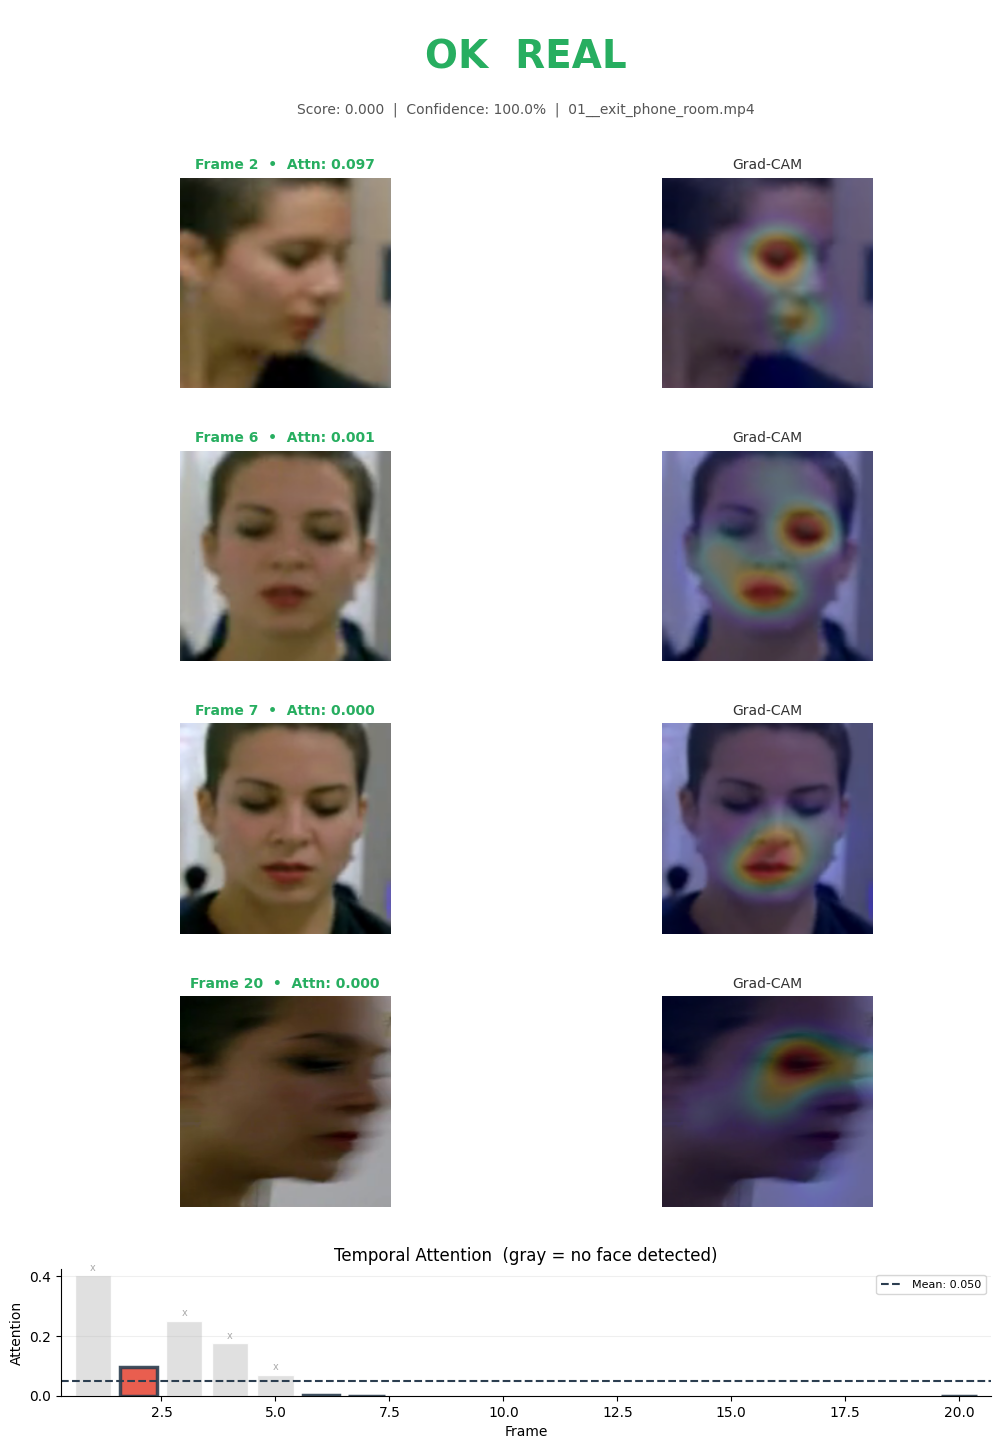


  DEEPFAKE ANALYSIS REPORT

  Video       : 01__exit_phone_room.mp4
  Verdict     : REAL
  Score       : 0.0004
  Confidence  : 100.0%
  Frames      : 20 analyzed


E0000 00:00:1772910362.677524 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910362.677567 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910362.677574 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910362.700071 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910362.700101 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910362.70


  --------------------------------------------------
  MANIPULATION SUMMARY
  --------------------------------------------------

  This video shows no indicators of manipulation.
  Facial features appear consistent and natural.
  Temporal patterns are uniform across frames,
  suggesting authentic video content.

  --------------------------------------------------
  KEY FINDINGS
  --------------------------------------------------

  --------------------------------------------------
  TEMPORAL ANALYSIS
  --------------------------------------------------

  Most suspicious frames  : 1, 3, 4, 2
  Mean attention weight   : 0.0500
  Attention std deviation : 0.1053
  Top-4 frame concentration: 92.8% of total attention
  High-attention frames   : 5/20
  Temporal consistency    : LOW (concentrated - indicates manipulation in specific frames)
  Faces detected          : 16/20 frames

  --------------------------------------------------
  CONFIDENCE BREAKDOWN
  ----------------------------

E0000 00:00:1772910376.599393 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910376.599432 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910376.599442 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910376.634405 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910376.634443 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910376.63

  Good face frames: 20/20
  Showing 4 best frames


E0000 00:00:1772910377.972300 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910377.972338 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910377.972346 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910378.680260 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910378.680298 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910378.68

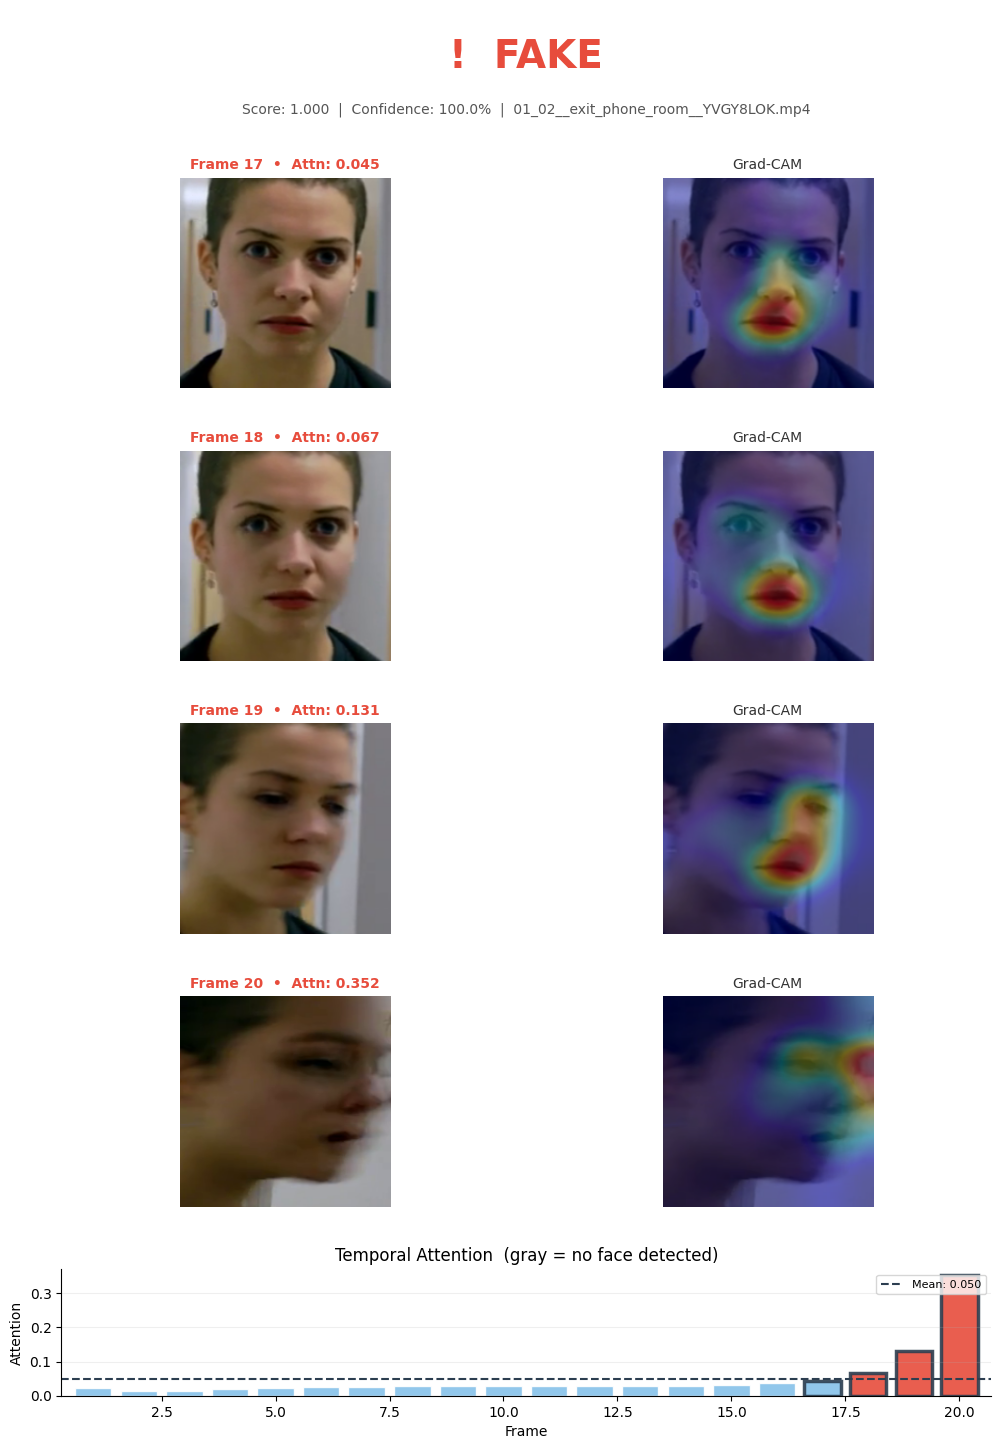


  DEEPFAKE ANALYSIS REPORT

  Video       : 01_02__exit_phone_room__YVGY8LOK.mp4
  Verdict     : FAKE
  Score       : 0.9998
  Confidence  : 100.0%
  Frames      : 20 analyzed


E0000 00:00:1772910380.692942 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910380.692979 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910380.692987 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910380.723730 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910380.723757 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772910380.72


  --------------------------------------------------
  MANIPULATION SUMMARY
  --------------------------------------------------

  This video shows strong indicators of facial manipulation.
  The model detected significant inconsistencies in
  the JAWLINE and EYE REGION.
  Temporal analysis reveals that frames 20, 19, 18, 17
  contain the most suspicious content, with attention
  weights 7.0x above average.

  --------------------------------------------------
  KEY FINDINGS
  --------------------------------------------------

  --------------------------------------------------
  TEMPORAL ANALYSIS
  --------------------------------------------------

  Most suspicious frames  : 20, 19, 18, 17
  Mean attention weight   : 0.0500
  Attention std deviation : 0.0736
  Top-4 frame concentration: 59.5% of total attention
  High-attention frames   : 3/20
  Temporal consistency    : LOW (concentrated - indicates manipulation in specific frames)
  Faces detected          : 20/20 frames

  --

In [120]:

# ==============================================================
# SECTION 9 — TEST ON DATASET
# ==============================================================
demo_test_paths  = np.load(os.path.join(SAVE_DIR, f'{PREFIX}paths.npy'))
demo_test_labels = np.load(os.path.join(SAVE_DIR, f'{PREFIX}labels.npy'))
demo_real_vids = demo_test_paths[demo_test_labels == 0]
demo_fake_vids = demo_test_paths[demo_test_labels == 1]
print(f'Dataset: {len(demo_real_vids)} real | {len(demo_fake_vids)} fake')

print('\n--- REAL video ---')
demo_visualize(demo_real_vids[0])

print('\n--- FAKE video ---')
demo_visualize(demo_fake_vids[0])

In [24]:
# ==============================================================
# SECTION 10 — BATCH TEST (SHOULD BE ~100%)
# ==============================================================
print('\n' + '=' * 60)
print('BATCH ACCURACY CHECK')
print('=' * 60)

demo_correct = 0
demo_total = 0

print('\nREAL videos:')
for v in demo_real_vids[:10]:
    lbl, _, sc, _, _ = demo_predict(v)
    ok = lbl == 'REAL'
    print(f'  {"OK" if ok else "XX"} {os.path.basename(v)}: {sc:.4f} -> {lbl}')
    demo_correct += int(ok); demo_total += 1

print('\nFAKE videos:')
for v in demo_fake_vids[:10]:
    lbl, _, sc, _, _ = demo_predict(v)
    ok = lbl == 'FAKE'
    print(f'  {"OK" if ok else "XX"} {os.path.basename(v)}: {sc:.4f} -> {lbl}')
    demo_correct += int(ok); demo_total += 1

print(f'\nBatch: {demo_correct}/{demo_total} = {demo_correct/demo_total*100:.0f}%')

print('\n' + '=' * 60)
print('DEMO STEP 3 COMPLETE ✅')
print('=' * 60)


BATCH ACCURACY CHECK

REAL videos:
  OK 01__exit_phone_room.mp4: 0.0004 -> REAL
  OK 01__hugging_happy.mp4: 0.0007 -> REAL
  OK 01__kitchen_pan.mp4: 0.0117 -> REAL
  OK 01__kitchen_still.mp4: 0.0044 -> REAL
  OK 01__meeting_serious.mp4: 0.0010 -> REAL
  OK 01__outside_talking_pan_laughing.mp4: 0.0000 -> REAL
  OK 01__outside_talking_still_laughing.mp4: 0.0002 -> REAL
  OK 01__podium_speech_happy.mp4: 0.0219 -> REAL
  OK 01__secret_conversation.mp4: 0.0024 -> REAL
  OK 01__talking_against_wall.mp4: 0.0268 -> REAL

FAKE videos:
  OK 01_02__exit_phone_room__YVGY8LOK.mp4: 0.9979 -> FAKE
  OK 01_02__hugging_happy__YVGY8LOK.mp4: 1.0000 -> FAKE
  OK 01_02__meeting_serious__YVGY8LOK.mp4: 0.9998 -> FAKE
  OK 01_02__outside_talking_still_laughing__YVGY8LOK.mp4: 1.0000 -> FAKE
  OK 01_02__secret_conversation__YVGY8LOK.mp4: 0.9989 -> FAKE
  OK 01_02__talking_against_wall__YVGY8LOK.mp4: 0.9935 -> FAKE
  OK 01_02__talking_angry_couch__YVGY8LOK.mp4: 0.9994 -> FAKE
  OK 01_02__walk_down_hall_angry__Y


Analyzing: /workspace/deepfake/03_06__hugging_happy__1IXGY2FK.mp4

Processing: 03_06__hugging_happy__1IXGY2FK.mp4
--------------------------------------------------


E0000 00:00:1772909778.716620 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772909778.716664 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772909778.716674 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772909778.751838 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772909778.751880 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772909778.75

  Good face frames: 20/20
  Showing 4 best frames


E0000 00:00:1772909780.055233 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772909780.055279 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772909780.055287 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772909780.754713 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772909780.754755 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772909780.75

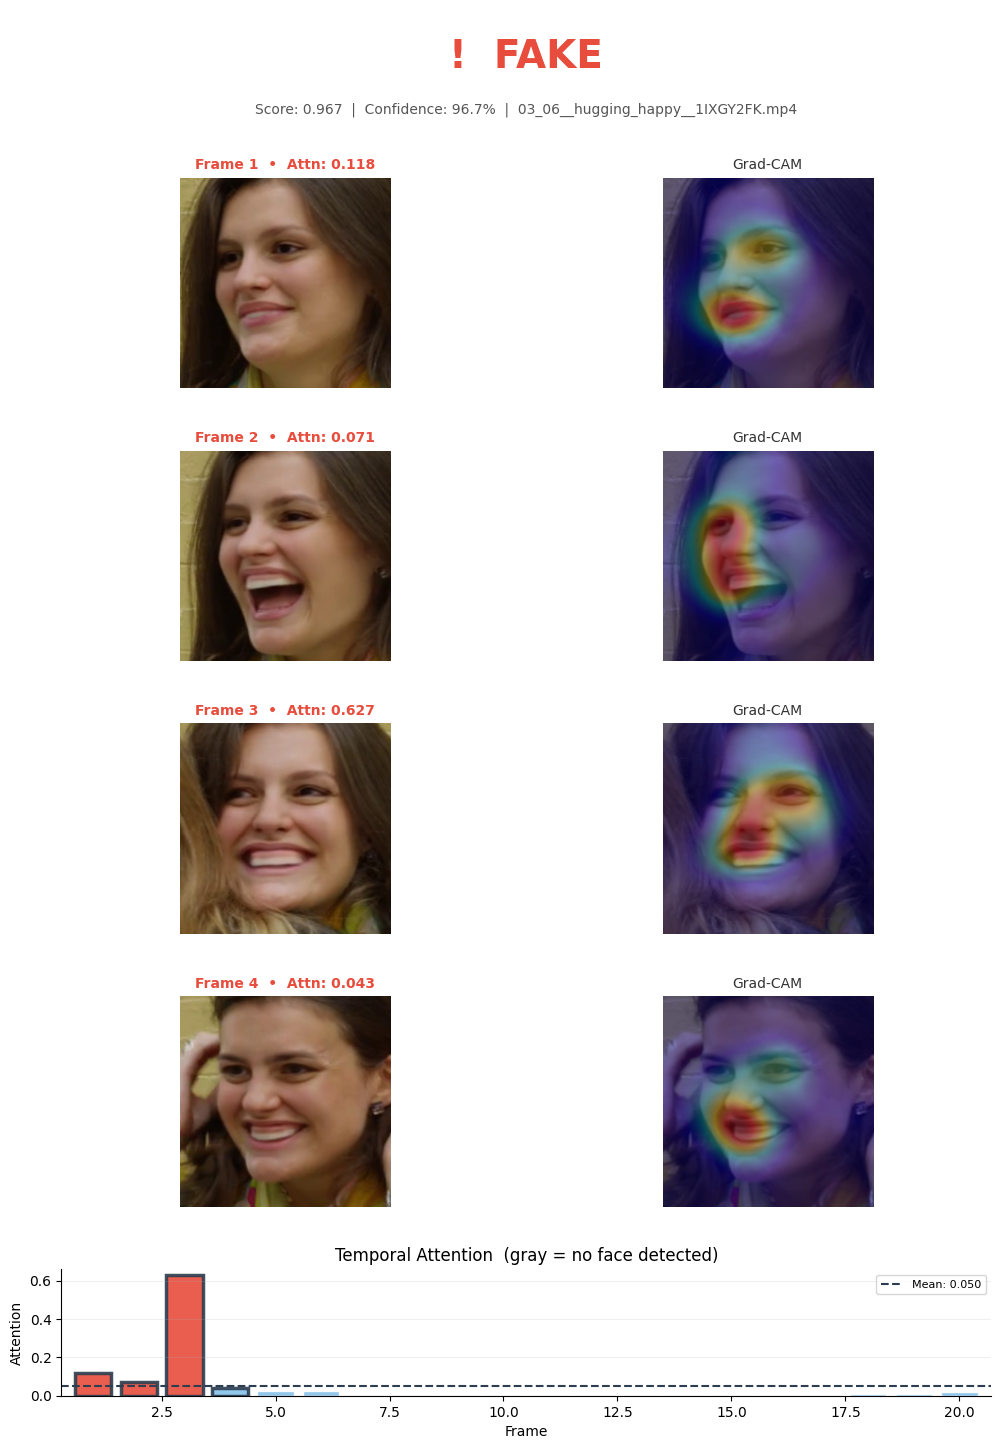


  DEEPFAKE ANALYSIS REPORT

  Video       : 03_06__hugging_happy__1IXGY2FK.mp4
  Verdict     : FAKE
  Score       : 0.9667
  Confidence  : 96.7%
  Frames      : 20 analyzed


E0000 00:00:1772909782.750500 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772909782.750545 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772909782.750553 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772909782.785534 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772909782.785580 4073253 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1772909782.78


  --------------------------------------------------
  MANIPULATION SUMMARY
  --------------------------------------------------

  This video shows strong indicators of facial manipulation.
  The model detected significant inconsistencies in
  the JAWLINE and MOUTH/TEETH.
  Temporal analysis reveals that frames 3, 1, 2, 4
  contain the most suspicious content, with attention
  weights 12.5x above average.

  --------------------------------------------------
  KEY FINDINGS
  --------------------------------------------------

  --------------------------------------------------
  TEMPORAL ANALYSIS
  --------------------------------------------------

  Most suspicious frames  : 3, 1, 2, 4
  Mean attention weight   : 0.0500
  Attention std deviation : 0.1353
  Top-4 frame concentration: 85.9% of total attention
  High-attention frames   : 3/20
  Temporal consistency    : LOW (concentrated - indicates manipulation in specific frames)
  Faces detected          : 20/20 frames

  --------

In [90]:
# ==============================================================
# SECTION 11 — PREDICT YOUR OWN VIDEO
# Change MY_VIDEO and run this cell
# ==============================================================

MY_VIDEO = '/workspace/deepfake/03_06__hugging_happy__1IXGY2FK.mp4'   # ← CHANGE THIS

if os.path.exists(MY_VIDEO):
    print(f'\nAnalyzing: {MY_VIDEO}')
    print('=' * 60)
    demo_visualize(MY_VIDEO)
else:
    print(f'File not found: {MY_VIDEO}')
    print(f'Change MY_VIDEO path and re-run this cell.')
    print(f'\nExamples:')
    print(f'  /workspace/deepfake/real-364/video.mp4')
    print(f'  /workspace/deepfake/previous-fake/video.mp4')

In [79]:
# ==============================================================
# SECTION 12 — QUICK TEST FUNCTION
# ==============================================================

def quick_test(video_path):
    """Instant text prediction — no visualization."""
    if not os.path.exists(video_path):
        print(f'File not found: {video_path}')
        return

    lbl, conf, sc, _, _ = demo_predict(video_path)

    print(f'\n  Video      : {os.path.basename(video_path)}')
    print(f'  Prediction : {lbl}')
    print(f'  Score      : {sc:.4f}')
    print(f'  Confidence : {conf*100:.1f}%')

    if lbl == 'FAKE':
        print(f'\n  WARNING: This video appears to be MANIPULATED')
    else:
        print(f'\n  OK: This video appears to be AUTHENTIC')


# Usage:
# quick_test('/workspace/deepfake/real-364/some_video.mp4')
# demo_visualize('/workspace/deepfake/previous-fake/some_video.mp4')

print('\n' + '=' * 60)
print('STEP 3 COMPLETE ✅')
print('=' * 60)
print('  quick_test(path)      — instant text result')
print('  demo_visualize(path)  — full Grad-CAM visualization')


STEP 3 COMPLETE ✅
  quick_test(path)      — instant text result
  demo_visualize(path)  — full Grad-CAM visualization
